# Feature Validation

## Project: Avoidable ED Utilization Navigator

---

## Objective

Validate the engineered CMS Medicare member-level feature dataset before applying machine learning models.

This validation ensures:

- Data integrity
- Feature correctness
- No duplicate beneficiary records
- No missing critical information
- Meaningful healthcare utilization patterns
- Model readiness

---

## Important Note

This system identifies:

"Historical healthcare utilization patterns and potential avoidable ED utilization opportunities"

It does NOT:

- Diagnose patients
- Decide whether an emergency is real
- Replace physician judgement

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load Engineered Feature Dataset

## Objective

Load the final member-level feature dataset generated during feature engineering.

Expected structure:

One row = One Medicare beneficiary

Each column = Healthcare utilization or demographic feature

In [2]:
FEATURE_PATH = "../processed_data/utilization_features.csv"

df = pd.read_csv(FEATURE_PATH)

print("Dataset loaded successfully")

df.head()

Dataset loaded successfully


,BENE_ID,age,gender,dual_eligibility_months,chronic_condition_count,inpatient_visit_count,inpatient_total_cost,outpatient_visit_count,outpatient_total_cost,ed_visit_count,total_claim_payment_amount,total_ed_related_cost,average_claim_cost,provider_count
0,-10000010254618,23,Male,0,0,1,96.65,74,382596.67,1,382693.32,96.65,5102.58,2
1,-10000010254647,32,Male,0,0,0,0.00,3,535.04,0,535.04,0.00,178.35,1
2,-10000010254653,40,Female,0,0,2,14857.60,37,558148.79,1,573006.39,6311.88,14692.47,3
3,-10000010254656,23,Female,0,0,3,14903.15,45,1053326.64,4,1068229.79,14903.15,22254.79,2
4,-10000010254666,13,Female,0,0,1,11706.13,1,237.17,1,11943.30,11706.13,5971.65,2


## Step 3: Dataset Size Validation

## Objective

Understand the size of the engineered dataset.

This confirms:

- Number of beneficiaries available
- Number of generated features

In [3]:
rows, columns = df.shape

print("Total Beneficiary Records:", rows)
print("Total Features:", columns)

Total Beneficiary Records: 8671
Total Features: 14


## Step 4: Feature Column Validation

## Objective

Verify that important engineered healthcare utilization features exist.

Expected feature categories:

### Member Profile
- Age
- Gender
- Chronic conditions

### Utilization
- ED visits
- Inpatient visits
- Outpatient visits

### Cost
- Total claim payment
- ED related cost
- Average claim cost

### Care Fragmentation
- Provider count

In [4]:
print("Available Features:\n")

for column in df.columns:
    print("-", column)

Available Features:

- BENE_ID
- age
- gender
- dual_eligibility_months
- chronic_condition_count
- inpatient_visit_count
- inpatient_total_cost
- outpatient_visit_count
- outpatient_total_cost
- ed_visit_count
- total_claim_payment_amount
- total_ed_related_cost
- average_claim_cost
- provider_count


## Step 5: Data Type Validation

## Objective

Validate whether each feature has the correct data type.

Expected:

Numeric:
- Visit counts
- Costs
- Age
- Provider count

Categorical:
- Gender

Identifier:
- BENE_ID

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8671 entries, 0 to 8670
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   BENE_ID                     8671 non-null   int64  
 1   age                         8671 non-null   int64  
 2   gender                      8671 non-null   str    
 3   dual_eligibility_months     8671 non-null   int64  
 4   chronic_condition_count     8671 non-null   int64  
 5   inpatient_visit_count       8671 non-null   int64  
 6   inpatient_total_cost        8671 non-null   float64
 7   outpatient_visit_count      8671 non-null   int64  
 8   outpatient_total_cost       8671 non-null   float64
 9   ed_visit_count              8671 non-null   int64  
 10  total_claim_payment_amount  8671 non-null   float64
 11  total_ed_related_cost       8671 non-null   float64
 12  average_claim_cost          8671 non-null   float64
 13  provider_count              8671 non-null   

# Step 6: Duplicate Beneficiary Validation

## Objective

Verify that the dataset contains one unique record per beneficiary.

## Reason

Each row should represent exactly one Medicare beneficiary.

Duplicate records can cause:

- Incorrect utilization calculation
- Biased model training
- Incorrect member risk estimation

Expected Result:

Duplicate beneficiary count should be zero.

In [6]:
total_records = len(df)

unique_members = df["BENE_ID"].nunique()

duplicate_records = total_records - unique_members


print("Total Records:", total_records)
print("Unique Beneficiaries:", unique_members)
print("Duplicate Beneficiary Records:", duplicate_records)

Total Records: 8671
Unique Beneficiaries: 8671
Duplicate Beneficiary Records: 0


# Step 7: Missing Value Validation

## Objective

Identify missing values in engineered features.

Missing healthcare information may affect:

- Model predictions
- Risk scoring
- Pattern detection

Critical model features should not contain missing values.

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)


if total_missing == 0:
    print("Validation Passed: No missing values detected")
else:
    print("Missing values require investigation")

Total Missing Values: 0
Validation Passed: No missing values detected


# Step 8: Statistical Feature Validation

## Objective

Analyze feature ranges and identify abnormal values.

Checks:

- Negative costs
- Negative visit counts
- Unrealistic values
- Outliers

In [9]:
df.describe()

,BENE_ID,age,dual_eligibility_months,chronic_condition_count,inpatient_visit_count,inpatient_total_cost,outpatient_visit_count,outpatient_total_cost,ed_visit_count,total_claim_payment_amount,total_ed_related_cost,average_claim_cost,provider_count
count,8.671000e+03,8671.000000,8671.0,8671.0,8671.000000,8.671000e+03,8671.000000,8.671000e+03,8671.000000,8.671000e+03,8.671000e+03,8.671000e+03,8671.000000
mean,-1.000001e+13,60.977742,0.0,0.0,2.404798,9.122923e+04,46.417945,1.573521e+05,4.967362,2.485813e+05,1.464038e+04,9.667981e+03,1.966209
std,9.615955e+03,21.569947,0.0,0.0,8.604304,9.618780e+05,106.978489,3.536586e+05,27.855567,1.028997e+06,4.427836e+04,4.064264e+04,0.870317
min,-1.000001e+13,0.000000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,-1.000001e+13,50.000000,0.0,0.0,0.000000,0.000000e+00,6.000000,8.689745e+03,0.000000,1.386681e+04,0.000000e+00,1.150625e+03,1.000000
50%,-1.000001e+13,66.000000,0.0,0.0,1.000000,2.158960e+03,12.000000,3.269972e+04,1.000000,5.815784e+04,1.650000e+02,3.232620e+03,2.000000
75%,-1.000001e+13,74.000000,0.0,0.0,3.000000,3.114704e+04,30.000000,1.522287e+05,3.000000,2.291237e+05,1.359291e+04,7.711690e+03,2.000000
max,-1.000001e+13,110.000000,0.0,0.0,367.000000,4.914106e+07,783.000000,9.453158e+06,1090.000000,4.917616e+07,1.477239e+06,1.514196e+06,6.000000


## Step 9: Negative Value Check

In [10]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns


negative_values = {}

for column in numeric_columns:

    count = (df[column] < 0).sum()

    if count > 0:
        negative_values[column] = count


negative_values

{'BENE_ID': np.int64(8671)}

# Step 10: ED Utilization Pattern Validation

## Objective

Understand historical emergency department utilization patterns.

This analysis helps define:

- High utilization members
- Utilization imbalance
- Model target strategy

Important:

High ED utilization does not automatically mean unnecessary ED usage.

It only represents historical utilization behaviour.

In [11]:
df["ed_visit_count"].describe()

count    8671.000000
mean        4.967362
std        27.855567
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max      1090.000000
Name: ed_visit_count, dtype: float64

In [12]:
ed_distribution = (
    df["ed_visit_count"]
    .value_counts()
    .sort_index()
)


ed_distribution.head(20)

ed_visit_count
0     3643
1     1497
2      855
3      617
4      362
5      277
6      209
7      201
8      128
9      103
10      53
11      53
12      39
13      47
14      37
15      32
16      41
17      22
18      21
19      28
Name: count, dtype: int64

## Step 11: ED Visit Distribution Visualization

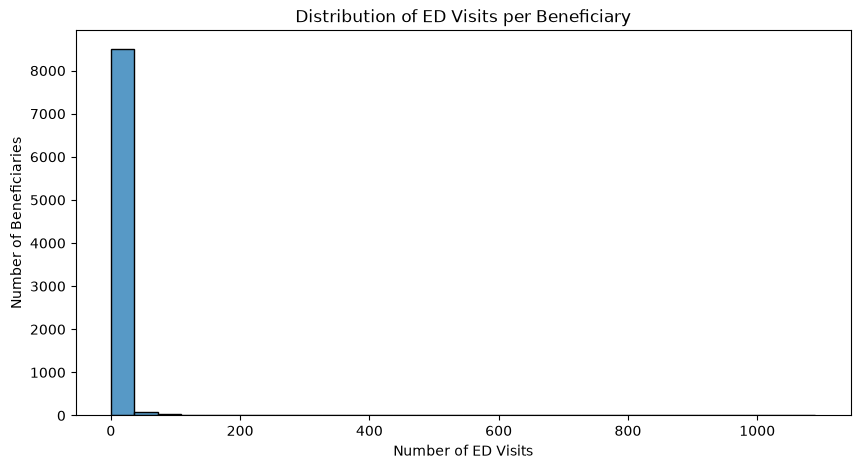

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["ed_visit_count"],
    bins=30
)

plt.title(
    "Distribution of ED Visits per Beneficiary"
)

plt.xlabel(
    "Number of ED Visits"
)

plt.ylabel(
    "Number of Beneficiaries"
)

plt.show()

# Step 12: Utilization Percentile Analysis

## Objective

Identify thresholds for high utilization patterns.

These thresholds will later support risk modelling.

This is NOT a clinical label.

In [14]:
percentiles = [50,75,90,95,99]


for percentile in percentiles:

    value = df["ed_visit_count"].quantile(
        percentile/100
    )

    print(
        f"{percentile}th Percentile:",
        value
    )

50th Percentile: 1.0
75th Percentile: 3.0
90th Percentile: 9.0
95th Percentile: 18.5
99th Percentile: 60.29999999999927


# Step 13: Cost Feature Validation

## Objective

Validate healthcare cost related features.

Used later for:

- Payer analytics
- Potential cost opportunity estimation

In [15]:
cost_features = [
    "total_claim_payment_amount",
    "total_ed_related_cost",
    "average_claim_cost"
]


df[cost_features].describe()

,total_claim_payment_amount,total_ed_related_cost,average_claim_cost
count,8.671000e+03,8.671000e+03,8.671000e+03
mean,2.485813e+05,1.464038e+04,9.667981e+03
std,1.028997e+06,4.427836e+04,4.064264e+04
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.386681e+04,0.000000e+00,1.150625e+03
50%,5.815784e+04,1.650000e+02,3.232620e+03
75%,2.291237e+05,1.359291e+04,7.711690e+03
max,4.917616e+07,1.477239e+06,1.514196e+06


## Step 14: Cost Distribution Visualization

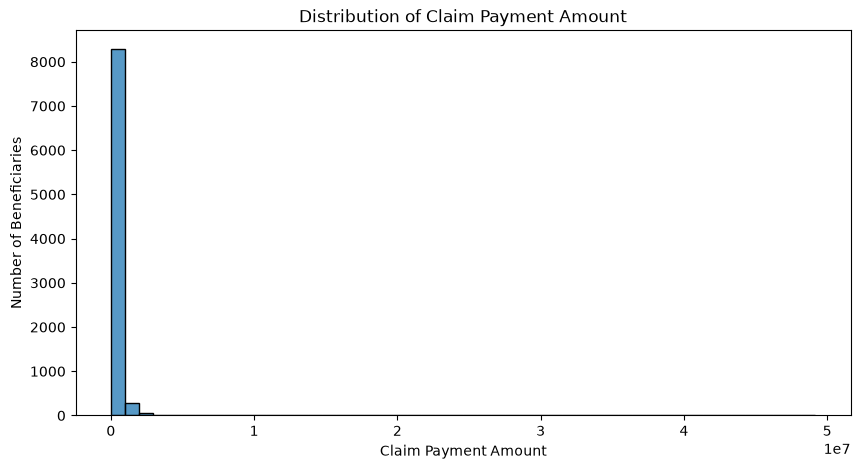

In [16]:
plt.figure(figsize=(10,5))


sns.histplot(
    df["total_claim_payment_amount"],
    bins=50
)


plt.title(
    "Distribution of Claim Payment Amount"
)

plt.xlabel(
    "Claim Payment Amount"
)

plt.ylabel(
    "Number of Beneficiaries"
)


plt.show()

# Step 15: Feature Correlation Analysis

## Objective

Understand relationships between utilization features.

This helps identify:

- Important predictors
- Feature relationships
- Possible redundancy

In [17]:
numeric_df = df.select_dtypes(
    include=np.number
)


correlation = numeric_df.corr()


correlation

,BENE_ID,age,dual_eligibility_months,chronic_condition_count,inpatient_visit_count,inpatient_total_cost,outpatient_visit_count,outpatient_total_cost,ed_visit_count,total_claim_payment_amount,total_ed_related_cost,average_claim_cost,provider_count
BENE_ID,1.000000,0.033267,NaN,NaN,0.011725,0.017894,0.006977,0.023508,0.009218,0.024806,0.012597,0.006671,0.042475
age,0.033267,1.000000,NaN,NaN,0.106711,0.021088,0.068122,-0.111475,0.120210,-0.018601,0.143862,-0.007903,0.071765
dual_eligibility_months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_condition_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inpatient_visit_count,0.011725,0.106711,NaN,NaN,1.000000,0.135537,0.093342,0.079145,0.966820,0.153897,0.823675,0.059111,0.185870
inpatient_total_cost,0.017894,0.021088,NaN,NaN,0.135537,1.000000,0.023764,0.012567,0.039202,0.939092,0.050901,0.767226,0.070090
outpatient_visit_count,0.006977,0.068122,NaN,NaN,0.093342,0.023764,1.000000,0.358815,0.086851,0.145536,0.078454,-0.056150,0.255759
outpatient_total_cost,0.023508,-0.111475,NaN,NaN,0.079145,0.012567,0.358815,1.000000,0.055775,0.355440,0.103521,0.115621,0.201321
ed_visit_count,0.009218,0.120210,NaN,NaN,0.966820,0.039202,0.086851,0.055775,1.000000,0.055814,0.831279,-0.013291,0.096530
total_claim_payment_amount,0.024806,-0.018601,NaN,NaN,0.153897,0.939092,0.145536,0.355440,0.055814,1.000000,0.083161,0.756920,0.134711


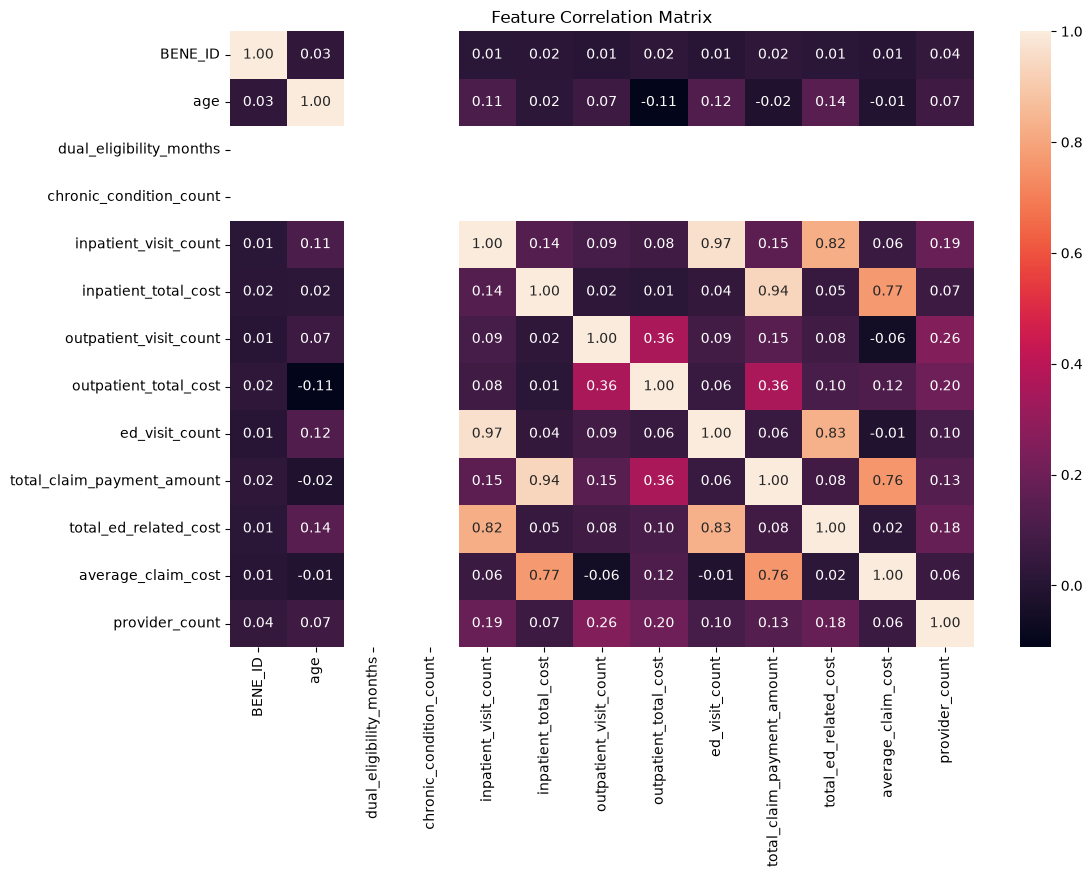

In [18]:
plt.figure(figsize=(12,8))


sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)


plt.title(
    "Feature Correlation Matrix"
)


plt.show()

## Step 16: ED Utilization Correlation

In [19]:
ed_relationship = (
    correlation["ed_visit_count"]
    .sort_values(
        ascending=False
    )
)


ed_relationship

ed_visit_count                1.000000
inpatient_visit_count         0.966820
total_ed_related_cost         0.831279
age                           0.120210
provider_count                0.096530
outpatient_visit_count        0.086851
total_claim_payment_amount    0.055814
outpatient_total_cost         0.055775
inpatient_total_cost          0.039202
BENE_ID                       0.009218
average_claim_cost           -0.013291
dual_eligibility_months            NaN
chronic_condition_count            NaN
Name: ed_visit_count, dtype: float64

# Step 17: Provider Fragmentation Validation

## Objective

Analyze provider count.

A higher provider count may indicate fragmented care.

This feature supports:

- Care continuity analysis
- Navigation recommendations

In [20]:
df["provider_count"].describe()

count    8671.000000
mean        1.966209
std         0.870317
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         6.000000
Name: provider_count, dtype: float64

# Step 18: Final Validation Report

Generate a summary before model training.

The dataset is considered ready when:

- Beneficiary IDs are unique
- Missing values are handled
- Features contain valid values
- Utilization patterns are meaningful

In [21]:
validation_report = {

    "Total Beneficiaries":
        len(df),

    "Unique Beneficiaries":
        df["BENE_ID"].nunique(),

    "Duplicate Records":
        df["BENE_ID"].duplicated().sum(),

    "Missing Values":
        int(df.isnull().sum().sum()),

    "Total Features":
        len(df.columns)

}


validation_report

{'Total Beneficiaries': 8671,
 'Unique Beneficiaries': 8671,
 'Duplicate Records': np.int64(0),
 'Missing Values': 0,
 'Total Features': 14}

## Step 19: Validation Decision

In [22]:
if (
    df["BENE_ID"].duplicated().sum() == 0
    and
    df.isnull().sum().sum() == 0
):

    print("✅ Feature Validation Passed")
    print("Dataset is ready for ML model training")

else:

    print("⚠️ Validation requires review")

✅ Feature Validation Passed
Dataset is ready for ML model training


## Step 20: Save Validation Report

In [24]:
import json

# Convert NumPy data types to normal Python types
validation_report = {
    key: int(value) if isinstance(value, np.integer)
    else float(value) if isinstance(value, np.floating)
    else value
    for key, value in validation_report.items()
}


with open(
    "../processed_data/feature_validation_report.json",
    "w"
) as file:

    json.dump(
        validation_report,
        file,
        indent=4
    )


print("Feature validation report saved successfully")

Feature validation report saved successfully


In [25]:
import sys

print(sys.executable)

d:\Projects\avoidable-ed-utilization-navigator\.venv\Scripts\python.exe
